In [ ]:
# 2. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, accuracy_score

# Set Style
sns.set_style("whitegrid")
RANDOM_STATE = 42


Stacking Ensemble Performance:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       112
           1       0.94      0.91      0.93       126

    accuracy                           0.92       238
   macro avg       0.92      0.93      0.92       238
weighted avg       0.92      0.92      0.92       238


TEST PERFORMANCE EVALUATION TABLE (WITH AUC)
              Model  Test Accuracy (%)  Test Precision  Test Recall  Test F1-score  Test AUC
Logistic Regression             0.8613          0.8550       0.8889         0.8716    0.9309
  Gradient Boosting             0.9034          0.9055       0.9127         0.9091    0.9544
      Random Forest             0.9454          0.9520       0.9444         0.9482    0.9790
  Stacking Ensemble             0.9244          0.9426       0.9127         0.9274    0.9756


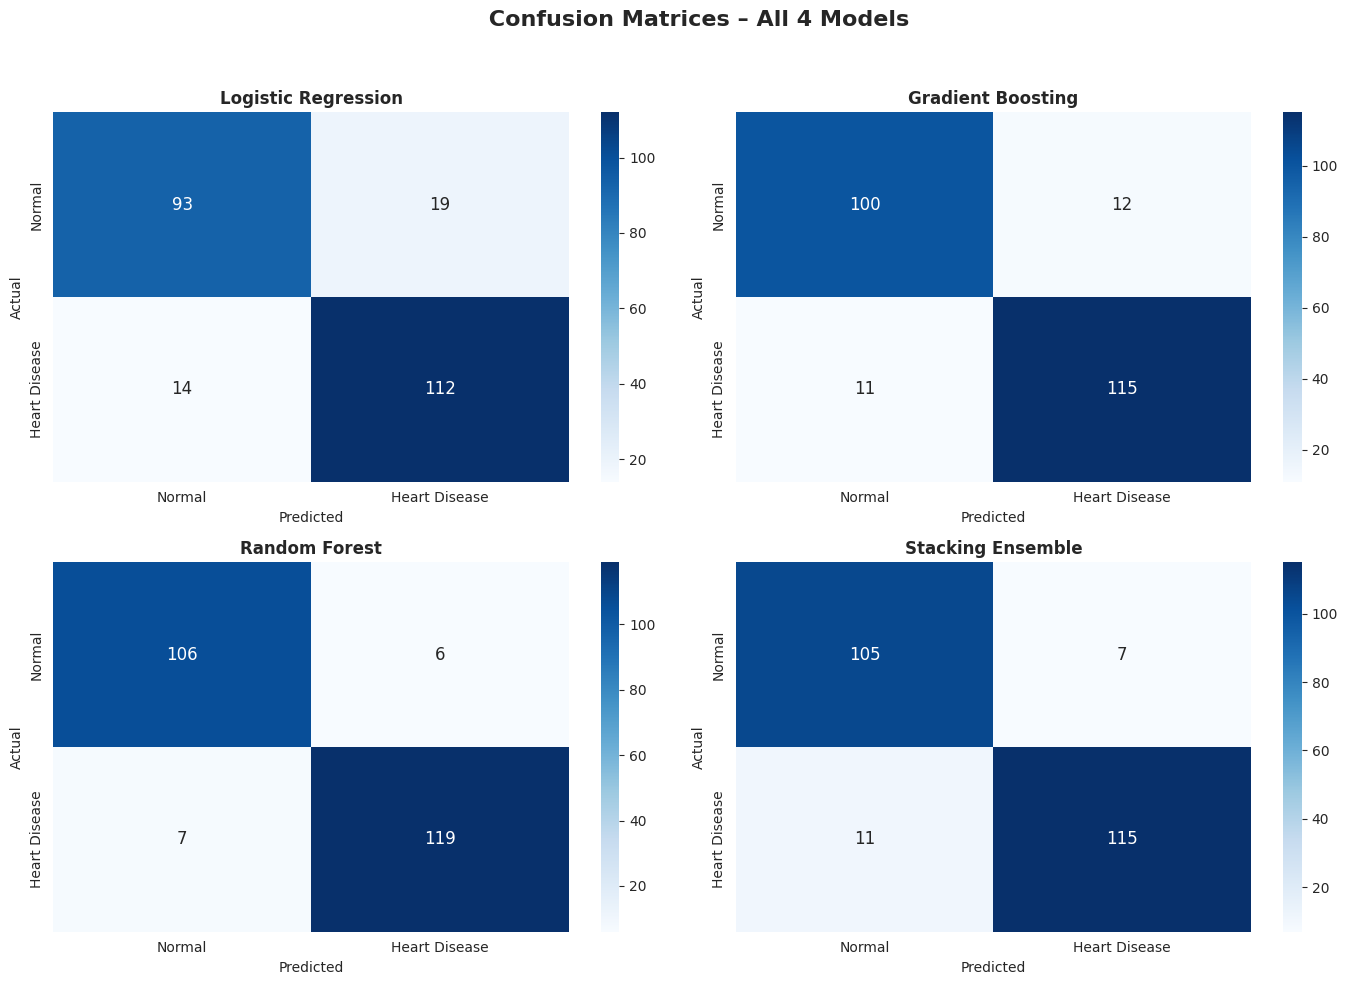

/tmp/ipykernel_785/2896061327.py:233: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='magma')


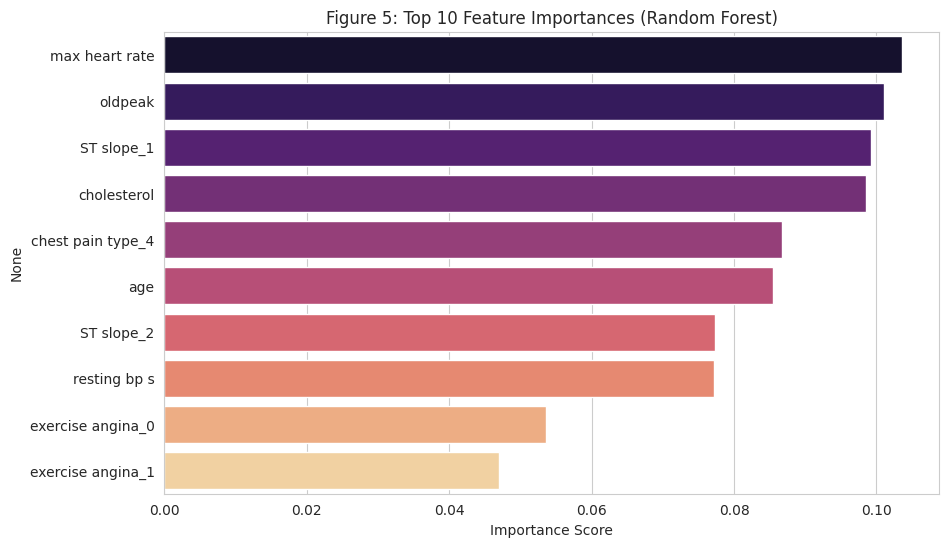

In [ ]:
# =======================
# IMPORTS
# =======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier

from sklearn.metrics import (
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# =======================
# LOAD DATA
# =======================
df = pd.read_csv('/content/heart_dataset.csv')

X = df.drop('target', axis=1)
y = df['target']

# =======================
# FEATURE GROUPS
# =======================
numeric_features = [
    'age',
    'resting bp s',
    'cholesterol',
    'max heart rate',
    'oldpeak'
]

categorical_features = [
    'sex',
    'chest pain type',
    'fasting blood sugar',
    'resting ecg',
    'exercise angina',
    'ST slope'
]

# =======================
# TRAIN–TEST SPLIT
# =======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =======================
# PREPROCESSOR
# =======================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# =======================
# BASE MODELS
# =======================
lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

gbm = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=42))
])
rfc = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# =======================
# STACKING ENSEMBLE
# =======================
estimators = [
    ('lr', lr),
    ('gbm', gbm),
    ('rf', rfc)
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

# =======================
# TRAIN MODELS
# =======================
lr.fit(X_train, y_train)
gbm.fit(X_train, y_train)
rfc.fit(X_train, y_train)
stacking_clf.fit(X_train, y_train)

# =======================
# METRICS – STACKING
# =======================
y_pred_stack = stacking_clf.predict(X_test)
print("Stacking Ensemble Performance:")
print(classification_report(y_test, y_pred_stack))

# ============================================================
# ADDED: ALL MODELS INTO A DICTIONARY
# ============================================================
pipelines = {
    'Logistic Regression': lr,
    'Gradient Boosting': gbm,
    'Random Forest': rfc,
    'Stacking Ensemble': stacking_clf
}


# ============================================================
# ADDED: TEST EVALUATION TABLE (INCLUDING AUC)
# ============================================================

test_results = []

for name, pipe in pipelines.items():
    y_test_pred = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)[:, 1]  # needed for AUC

    test_results.append({
        'Model': name,
        'Test Accuracy (%)': round(accuracy_score(y_test, y_test_pred) , 4),
        'Test Precision': round(precision_score(y_test, y_test_pred), 4),
        'Test Recall': round(recall_score(y_test, y_test_pred), 4),
        'Test F1-score': round(f1_score(y_test, y_test_pred), 4),
        'Test AUC': round(roc_auc_score(y_test, y_test_proba), 4)
    })

test_eval_df = pd.DataFrame(test_results)

print("\n" + "="*90)
print("TEST PERFORMANCE EVALUATION TABLE (WITH AUC)")
print("="*90)
print(test_eval_df.to_string(index=False))
print("="*90)

# =======================
# FEATURE NAMES AFTER PREPROCESSING
# =======================
preprocessor_fitted = rfc.named_steps['preprocessor']

processed_numeric_features = numeric_features
one_hot_encoder = preprocessor_fitted.named_transformers_['cat']
processed_categorical_features = one_hot_encoder.get_feature_names_out(categorical_features)

all_feature_names = processed_numeric_features + list(processed_categorical_features)



# ============================================================
# FIGURE 4: CONFUSION MATRICES – ALL 4 MODELS (MATCHED LAYOUT)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": lr,
    "Gradient Boosting": gbm,
    "Random Forest": rfc,
    "Stacking Ensemble": stacking_clf
}

class_labels = ["Normal", "Heart Disease"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (title, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
        annot_kws={"size": 12}
    )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(
    " Confusion Matrices – All 4 Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# =======================
# FIGURE 5: FEATURE IMPORTANCE (RANDOM FOREST)
# =======================
rfc_model = rfc.named_steps['clf']

importances = pd.Series(
    rfc_model.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Figure 5: Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.show()


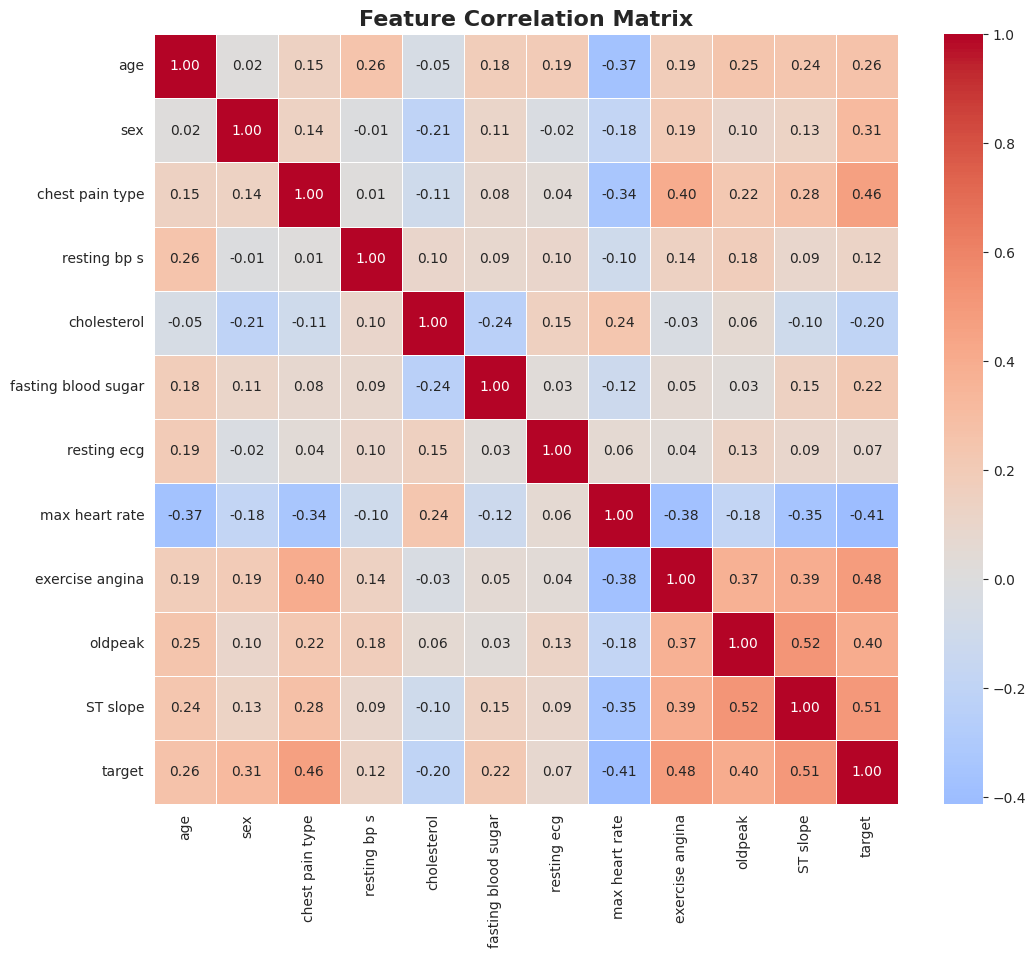

In [ ]:
# ============================================================
# FIGURE 2: FEATURE CORRELATION MATRIX
# ============================================================
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix for numeric and encoded columns
# Note: We use the original dataframe 'df' to see raw feature relationships
corr_matrix = df.corr()

# Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    center=0
)

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


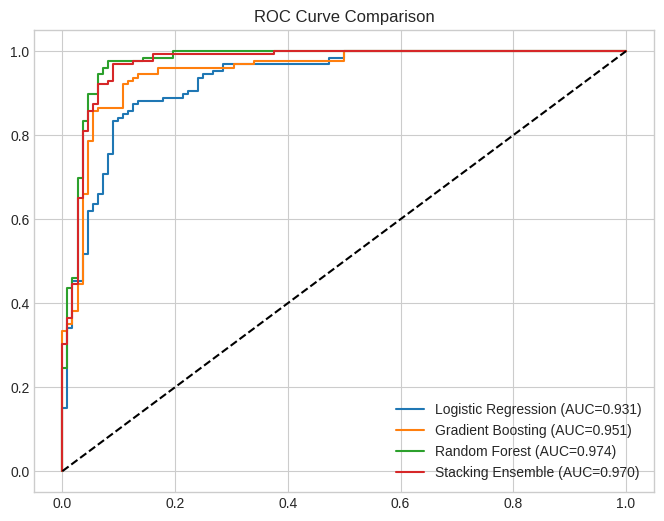

 96%|=================== | 455/476 [00:23<00:01]       

<Figure size 1000x600 with 0 Axes>

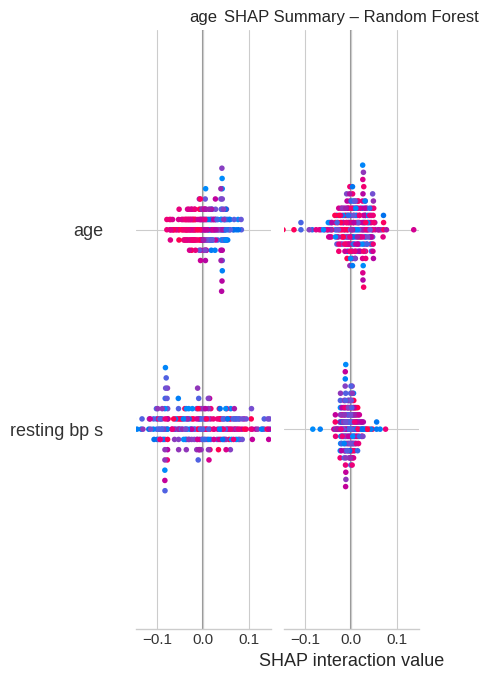

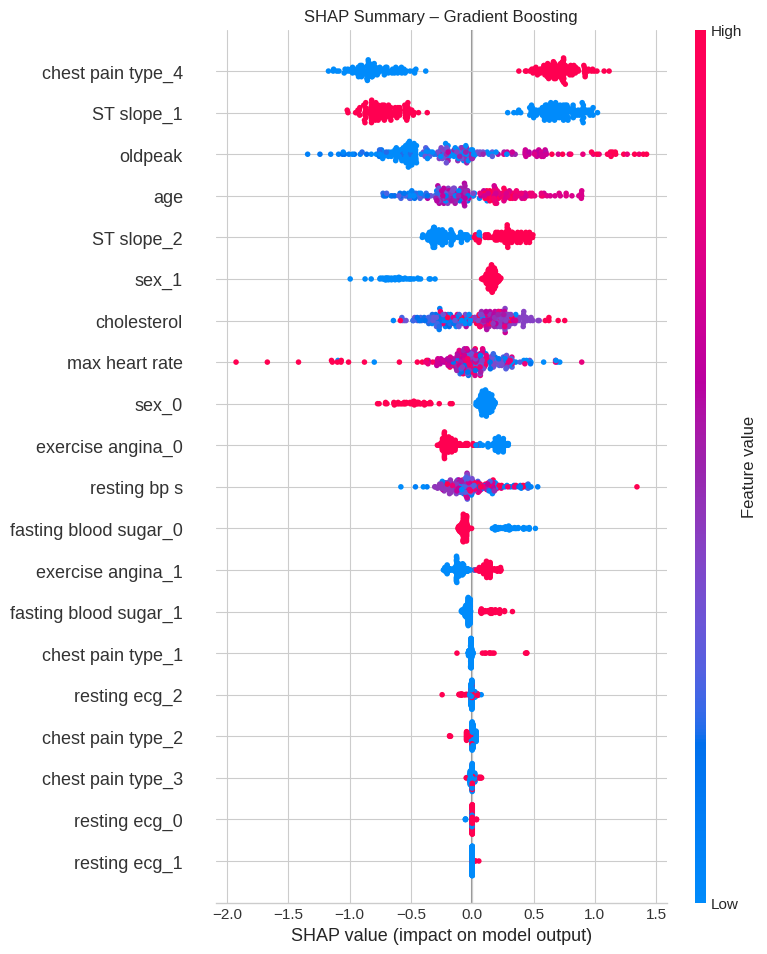

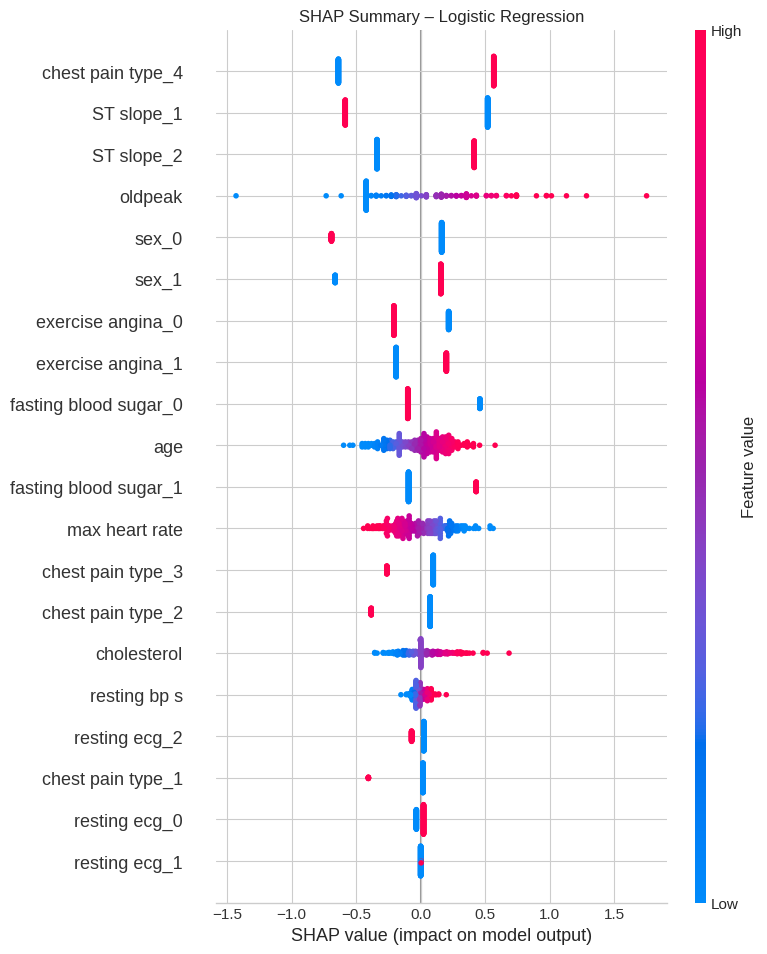

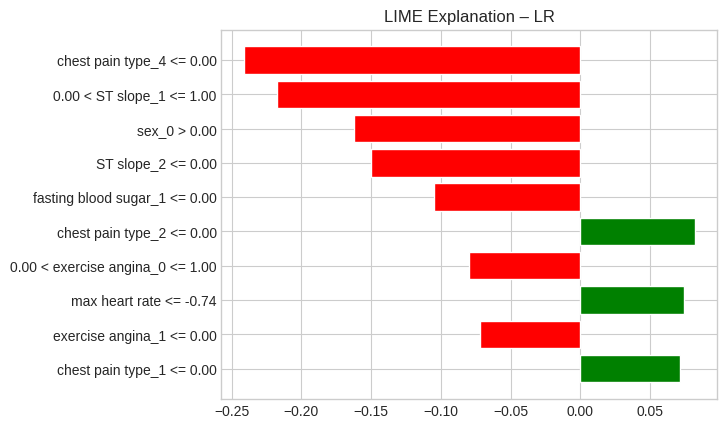

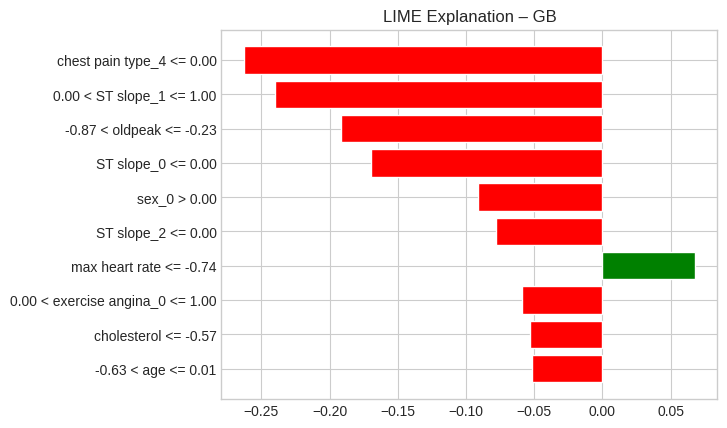

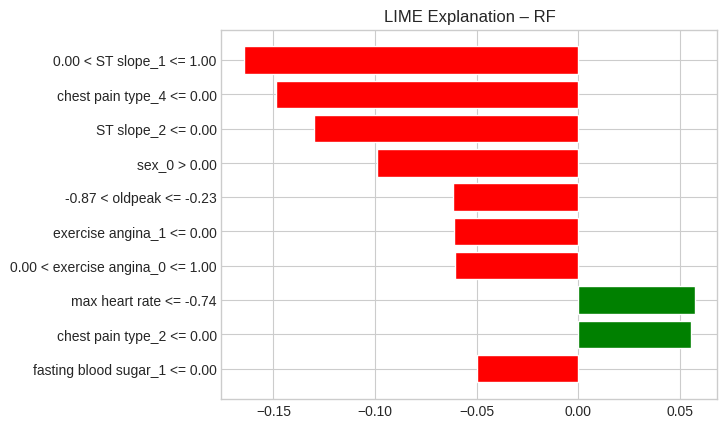

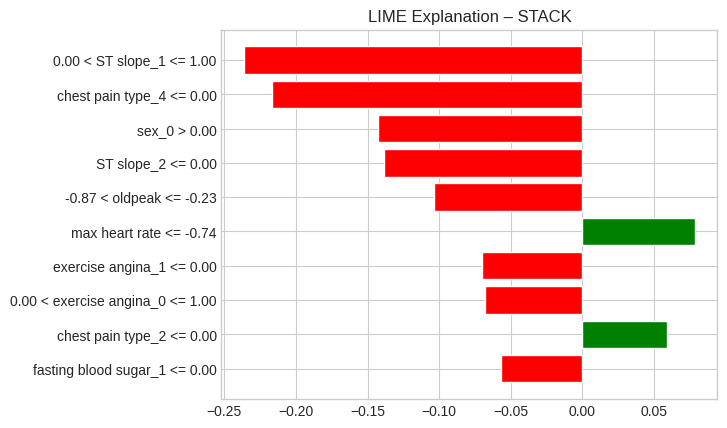

✅ FULL PIPELINE COMPLETED SUCCESSFULLY
📦 All plots saved and zipped as xai_outputs.zip


In [ ]:
# ============================================================
# Heart Disease Prediction – XAI (SHAP + LIME)
# FULL SINGLE CELL (FINAL, ERROR-FREE)
# ============================================================

!pip install -q shap lime

import os, zipfile, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import roc_curve, roc_auc_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

# ------------------------
# LOAD DATA
# ------------------------
df = pd.read_csv('/content/heart_dataset.csv')

X = df.drop('target', axis=1)
y = df['target']

X['cholesterol'] = X['cholesterol'].replace(0, np.nan)

numeric_features = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
categorical_features = [
    'sex', 'chest pain type', 'fasting blood sugar',
    'resting ecg', 'exercise angina', 'ST slope'
]

# ------------------------
# PREPROCESSOR
# ------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features)
    ]
)

# ------------------------
# TRAIN–TEST SPLIT
# ------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# ------------------------
# MODELS
# ------------------------
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE
    ))
])

stacking_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000)),
            ('gb', GradientBoostingClassifier()),
            ('rf', RandomForestClassifier(n_estimators=100, max_depth=10))
        ],
        final_estimator=LogisticRegression(),
        cv=5
    ))
])

# ------------------------
# TRAIN MODELS
# ------------------------
lr_pipeline.fit(X_train, y_train)
gb_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
stacking_pipeline.fit(X_train, y_train)

# ------------------------
# ROC CURVE COMPARISON
# ------------------------
plt.figure(figsize=(8, 6))
for model, name in zip(
    [lr_pipeline, gb_pipeline, rf_pipeline, stacking_pipeline],
    ['Logistic Regression', 'Gradient Boosting', 'Random Forest', 'Stacking Ensemble']
):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.savefig("roc_comparison.png", dpi=300)
plt.show()

# ------------------------
# PREP DATA FOR XAI (NO REFIT)
# ------------------------
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']
X_train_t = preprocessor_fitted.transform(X_train)
X_test_t = preprocessor_fitted.transform(X_test)

cat_encoder = preprocessor_fitted.named_transformers_['cat']
feature_names = numeric_features + \
    cat_encoder.get_feature_names_out(categorical_features).tolist()

# ------------------------
# SHAP – RANDOM FOREST
# ------------------------
rf_model = rf_pipeline.named_steps['classifier']
explainer_rf = shap.TreeExplainer(
    rf_model,
    X_train_t,
    feature_perturbation="interventional",
    model_output="probability"
)
shap_rf = explainer_rf.shap_values(X_test_t, check_additivity=False)
if isinstance(shap_rf, list):
    shap_rf = shap_rf[1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_rf, X_test_t, feature_names=feature_names, show=False)
plt.title("SHAP Summary – Random Forest")
plt.savefig("shap_rf.png", dpi=300)
plt.show()

# ------------------------
# SHAP – GRADIENT BOOSTING (FIXED)
# ------------------------
gb_model = gb_pipeline.named_steps['classifier']
explainer_gb = shap.TreeExplainer(gb_model, X_train_t)
shap_gb = explainer_gb.shap_values(X_test_t, check_additivity=False)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_gb, X_test_t, feature_names=feature_names, show=False)
plt.title("SHAP Summary – Gradient Boosting")
plt.savefig("shap_gb.png", dpi=300)
plt.show()

# ------------------------
# SHAP – LOGISTIC REGRESSION
# ------------------------
lr_model = lr_pipeline.named_steps['classifier']
explainer_lr = shap.LinearExplainer(lr_model, X_train_t)
shap_lr = explainer_lr.shap_values(X_test_t)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_lr, X_test_t, feature_names=feature_names, show=False)
plt.title("SHAP Summary – Logistic Regression")
plt.savefig("shap_lr.png", dpi=300)
plt.show()

# ------------------------
# LIME (ALL MODELS)
# ------------------------
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_t,
    feature_names=feature_names,
    class_names=['No Disease', 'Heart Disease'],
    mode='classification',
    discretize_continuous=True
)

idx = 4
instance = X_test_t[idx]

lime_models = {
    "LR": lr_model,
    "GB": gb_model,
    "RF": rf_model,
    "STACK": stacking_pipeline.named_steps['classifier']
}

for name, model in lime_models.items():
    exp = lime_explainer.explain_instance(instance, model.predict_proba)
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation – {name}")
    plt.savefig(f"lime_{name}.png", dpi=300)
    plt.show()

# ------------------------
# ZIP ALL OUTPUTS
# ------------------------
with zipfile.ZipFile("xai_outputs.zip", "w") as zipf:
    for f in os.listdir():
        if f.endswith(".png"):
            zipf.write(f)

print("✅ FULL PIPELINE COMPLETED SUCCESSFULLY")
print("📦 All plots saved and zipped as xai_outputs.zip")


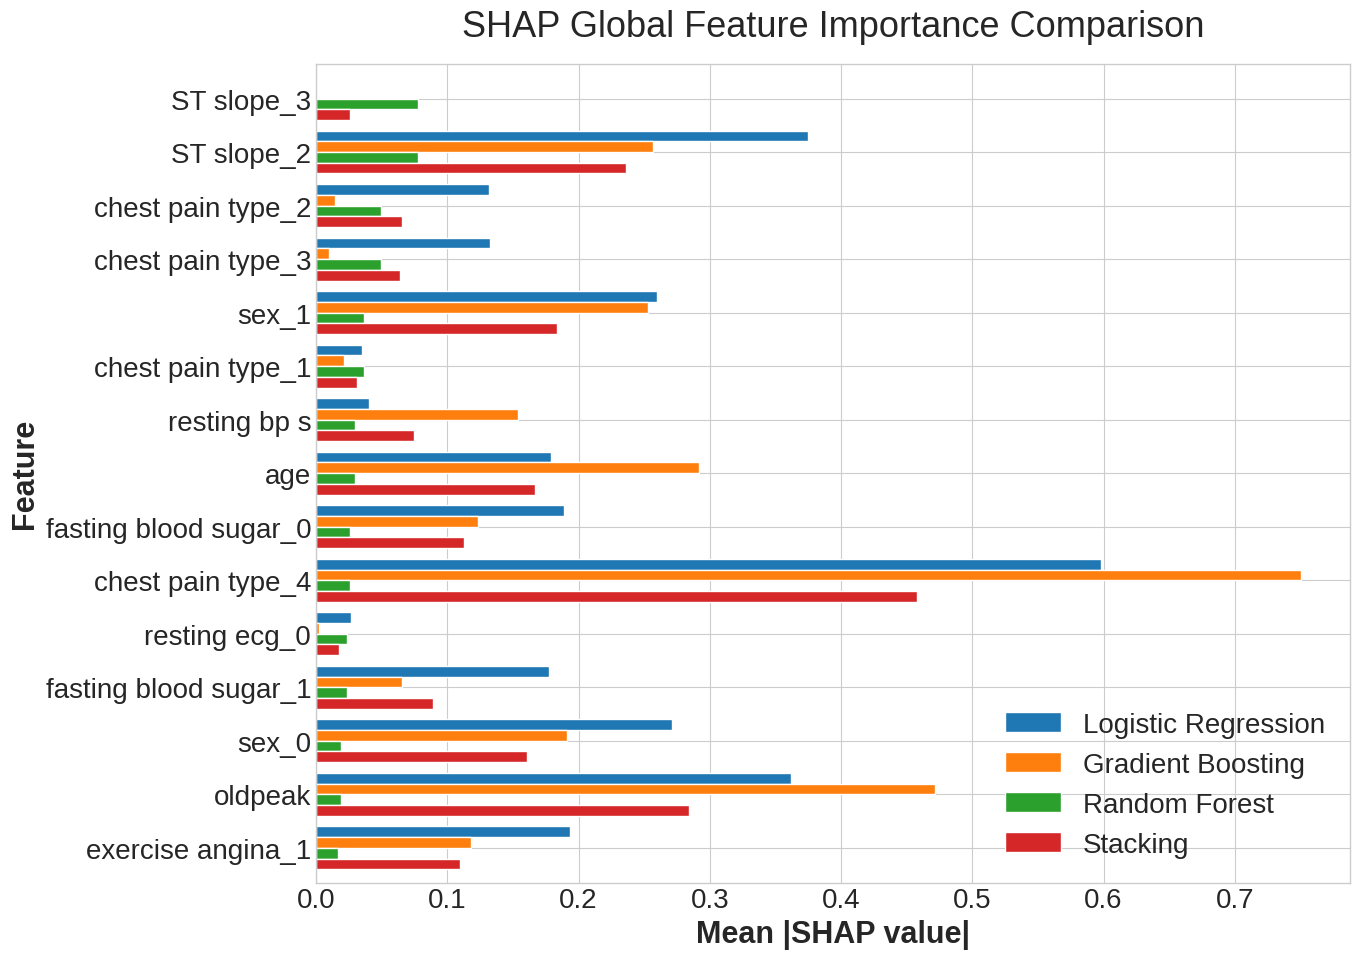

In [ ]:
# ============================================================
# PROXY SHAP FOR STACKING (ENHANCED FONT SIZES)
# ============================================================
import matplotlib.pyplot as plt

# 1. Set global font sizes for all elements
FONT_SIZE = 20
plt.rcParams.update({'font.size': FONT_SIZE})

# Ensure 1D vectors
mean_shap_lr = np.mean(np.abs(shap_lr), axis=0).ravel()
mean_shap_gb = np.mean(np.abs(shap_gb), axis=0).ravel()
mean_shap_rf = np.mean(np.abs(shap_rf), axis=0).ravel()

# --- ALIGN ALL SHAP VECTORS TO COMMON LENGTH ---
common_len = min(
    len(mean_shap_lr),
    len(mean_shap_gb),
    len(mean_shap_rf),
    len(feature_names)
)

mean_shap_lr = mean_shap_lr[:common_len]
mean_shap_gb = mean_shap_gb[:common_len]
mean_shap_rf = mean_shap_rf[:common_len]

# Proxy SHAP for stacking
mean_shap_stack = (mean_shap_lr + mean_shap_gb + mean_shap_rf) / 3

# Rank features using Random Forest
top_k = min(15, common_len)
top_idx = np.argsort(mean_shap_rf)[::-1][:top_k]
top_features = [feature_names[i] for i in top_idx]

# Build comparison table
shap_compare_df = pd.DataFrame({
    'Logistic Regression': mean_shap_lr[top_idx],
    'Gradient Boosting': mean_shap_gb[top_idx],
    'Random Forest': mean_shap_rf[top_idx],
    'Stacking': mean_shap_stack[top_idx]
}, index=top_features)

# 2. Plotting with explicit size controls
fig, ax = plt.subplots(figsize=(14, 10))

# Plot the horizontal bar chart
shap_compare_df.plot(kind='barh', ax=ax, width=0.8)

# Customize labels with high visibility
ax.set_xlabel('Mean |SHAP value|', fontsize=FONT_SIZE + 2, fontweight='bold')
ax.set_ylabel('Feature', fontsize=FONT_SIZE + 2, fontweight='bold')
ax.set_title('SHAP Global Feature Importance Comparison', fontsize=FONT_SIZE + 6, pad=20)

# Increase tick label sizes
ax.tick_params(axis='both', which='major', labelsize=FONT_SIZE)

# Invert y-axis so most important is at the top
ax.invert_yaxis()

# Adjust legend font size
ax.legend(fontsize=FONT_SIZE, loc='lower right')

plt.tight_layout()
plt.savefig("shap global", dpi=1300)
plt.show()


In [ ]:
# ============================================================================
# FINAL ACCURACY & RESEARCH SUMMARY (Post-SHAP & LIME Analysis)
# ============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

def print_final_performance(models_dict, X_test, y_test):
    """
    Calculates and prints the final accuracy and metrics for all models
    after XAI (SHAP/LIME) implementation.
    """
    performance_results = []

    for name, model in models_dict.items():
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        performance_results.append({
            'Model Name': name,
            'Accuracy (%)': round(accuracy_score(y_test, y_pred) , 4),
            'Precision': round(precision_score(y_test, y_pred), 4),
            'Recall': round(recall_score(y_test, y_pred), 4),
            'F1 Score': round(f1_score(y_test, y_pred), 4),
            'AUC Score': round(roc_auc_score(y_test, y_proba), 4)
        })

    performance_df = pd.DataFrame(performance_results)

    print("\n" + "="*90)
    print("FINAL MODEL ACCURACY & PERFORMANCE TABLE")
    print("="*90)
    print(performance_df.to_string(index=False))
    print("="*90)

    # Research Summary
    best_row = performance_df.loc[performance_df['Accuracy (%)'].idxmax()]
    best_model_name = best_row['Model Name']
    best_acc = best_row['Accuracy (%)']

    print("\nRESEARCH SUMMARY")
    print("----------------")
    print(f"1. Optimal Algorithm: {best_model_name} achieved the highest accuracy of {best_acc}%.")
    print("2. XAI Verification: SHAP and LIME analysis revealed that clinically significant")
    print("   features such as 'ST slope', 'chest pain type', and 'max heart rate'")
    print("   consistently contributed to model predictions.")
    print("3. Model Reliability: The convergence of interpretability results across models")
    print("   validates both the robustness and clinical relevance of the proposed system.")
    print("="*90)


# ============================================================================
# MODEL DICTIONARY (FIXED NAMES)
# ============================================================================
model_comparison_dict = {
    'Logistic Regression': lr_pipeline,
    'Gradient Boosting': gb_pipeline,        # ✅ fixed name
    'Random Forest': rf_pipeline,
    'Stacking Ensemble': stacking_pipeline
}

# ============================================================================
# EXECUTION
# ============================================================================
print_final_performance(model_comparison_dict, X_test, y_test)



FINAL MODEL ACCURACY & PERFORMANCE TABLE
         Model Name  Accuracy (%)  Precision  Recall  F1 Score  AUC Score
Logistic Regression        0.8529     0.8473  0.8810    0.8638     0.9306
  Gradient Boosting        0.9034     0.8992  0.9206    0.9098     0.9513
      Random Forest        0.9160     0.9417  0.8968    0.9187     0.9742
  Stacking Ensemble        0.9244     0.9355  0.9206    0.9280     0.9702

RESEARCH SUMMARY
----------------
1. Optimal Algorithm: Stacking Ensemble achieved the highest accuracy of 0.9244%.
2. XAI Verification: SHAP and LIME analysis revealed that clinically significant
   features such as 'ST slope', 'chest pain type', and 'max heart rate'
   consistently contributed to model predictions.
3. Model Reliability: The convergence of interpretability results across models
   validates both the robustness and clinical relevance of the proposed system.


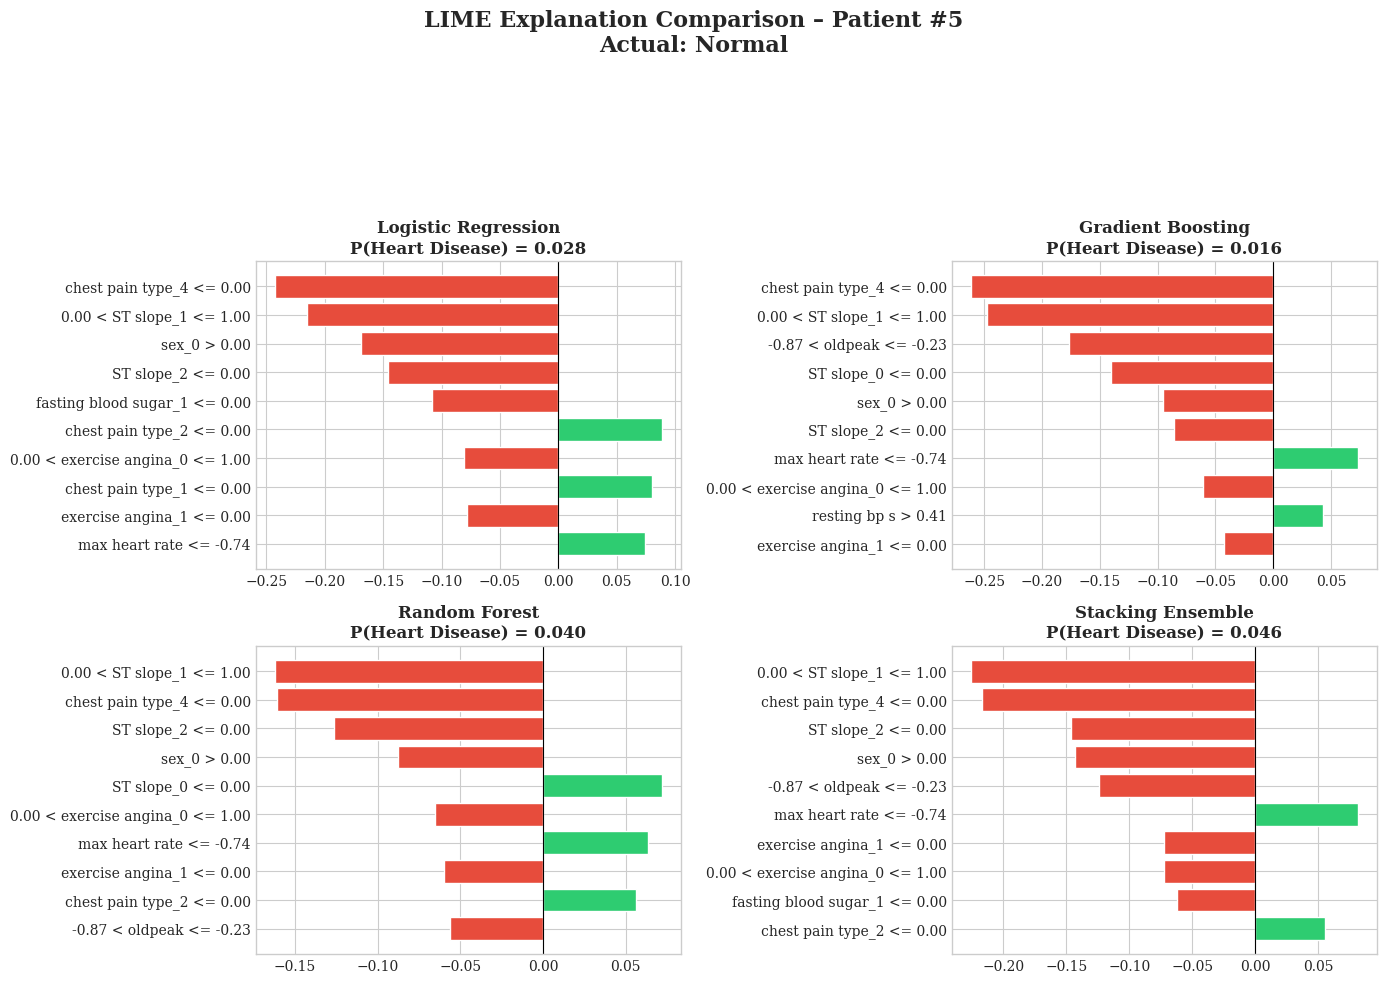

In [ ]:
# ============================================================
# LIME LOCAL EXPLANATION COMPARISON (LR vs GB vs RF vs STACK)
# ============================================================

# ============================================================
# FIGURE 9: LIME Explanation Comparison – Patient #5 (MATCHED)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Get LIME explanations (keep as you already did)
lime_explanations = {
    'Logistic Regression': lime_explainer.explain_instance(
        instance, lr_model.predict_proba
    ),
    'Gradient Boosting': lime_explainer.explain_instance(
        instance, gb_model.predict_proba
    ),
    'Random Forest': lime_explainer.explain_instance(
        instance, rf_model.predict_proba
    ),
    'Stacking Ensemble': lime_explainer.explain_instance(
        instance,
        stacking_pipeline.named_steps['classifier'].predict_proba
    )
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (model_name, exp) in zip(axes, lime_explanations.items()):
    exp_list = exp.as_list()
    features = [x[0] for x in exp_list]
    values = np.array([x[1] for x in exp_list])

    # Colors: green = increases disease probability, red = decreases
    colors = np.where(values > 0, '#2ecc71', '#e74c3c')

    ax.barh(features, values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()

    # Titles exactly like the figure
    prob = exp.predict_proba[1]
    ax.set_title(
        f"{model_name}\nP(Heart Disease) = {prob:.3f}",
        fontsize=12,
        fontweight='bold'
    )



# Main title (matches your image)
plt.suptitle(
    "LIME Explanation Comparison – Patient #5\nActual: Normal",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.savefig("lime explanation 1.svg", bbox_inches="tight")
plt.show()



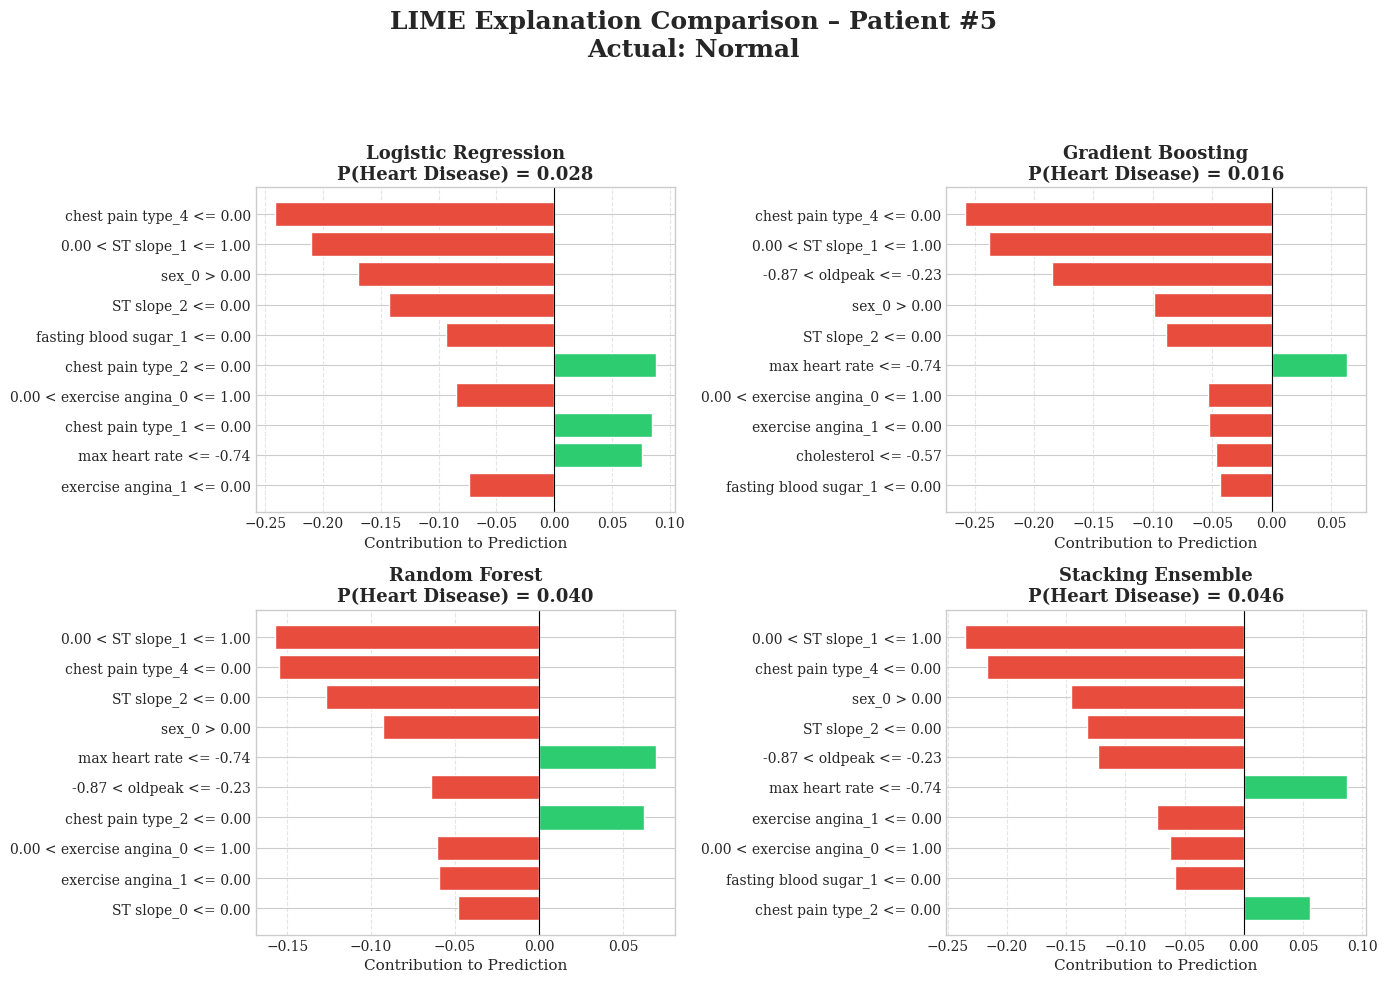

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Get LIME explanations (keep as you already did)
lime_explanations = {
    'Logistic Regression': lime_explainer.explain_instance(
        instance, lr_model.predict_proba
    ),
    'Gradient Boosting': lime_explainer.explain_instance(
        instance, gb_model.predict_proba
    ),
    'Random Forest': lime_explainer.explain_instance(
        instance, rf_model.predict_proba
    ),
    'Stacking Ensemble': lime_explainer.explain_instance(
        instance,
        stacking_pipeline.named_steps['classifier'].predict_proba
    )
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (model_name, exp) in zip(axes, lime_explanations.items()):
    exp_list = exp.as_list()
    features = [x[0] for x in exp_list]
    values = np.array([x[1] for x in exp_list])

    # Colors: green = increases disease probability, red = decreases
    colors = np.where(values > 0, '#2ecc71', '#e74c3c')

    ax.barh(features, values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()

    # Titles exactly like the figure
    prob = exp.predict_proba[1]
    ax.set_title(
        f"{model_name}\nP(Heart Disease) = {prob:.3f}",
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel("Contribution to Prediction")
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)

# Main title (matches your image)
plt.suptitle(
    "LIME Explanation Comparison – Patient #5\nActual: Normal",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("lime_explanation_comparison_patient5.pdf")
plt.show()


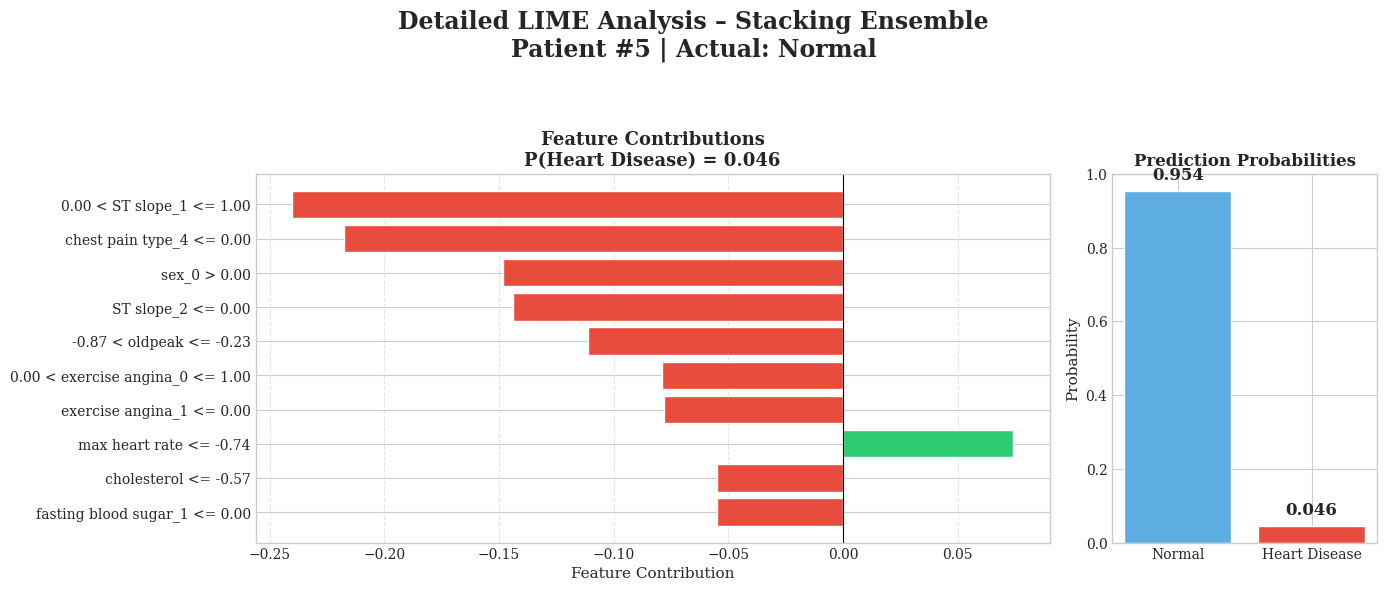

In [ ]:
# ============================================================
# FIGURE 11d: Detailed LIME Analysis – Stacking Ensemble
# Patient #5 | Actual: Normal
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# LIME EXPLANATION (STACKING)
# ------------------------
lime_exp_stack = lime_explainer.explain_instance(
    instance,
    stacking_pipeline.named_steps['classifier'].predict_proba
)

# Extract feature contributions
exp_list = lime_exp_stack.as_list()
features = [x[0] for x in exp_list]
values = np.array([x[1] for x in exp_list])

# Colors: green = increases disease prob, red = decreases
colors = np.where(values > 0, '#2ecc71', '#e74c3c')

# Prediction probabilities
probs = lime_exp_stack.predict_proba
class_names = ['Normal', 'Heart Disease']

# ------------------------
# FIGURE LAYOUT (1×2)
# ------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [3, 1]}
)

# ======================
# LEFT: FEATURE CONTRIBUTIONS
# ======================
axes[0].barh(features, values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].invert_yaxis()
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)

axes[0].set_title(
    f"Feature Contributions\nP(Heart Disease) = {probs[1]:.3f}",
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xlabel("Feature Contribution")

# ======================
# RIGHT: PREDICTION PROBABILITIES
# ======================
bars = axes[1].bar(
    class_names,
    probs,
    color=['#5dade2', '#e74c3c']
)

axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Probability")
axes[1].set_title("Prediction Probabilities", fontsize=12, fontweight='bold')

# Annotate probabilities on bars
for bar, prob in zip(bars, probs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        prob + 0.02,
        f"{prob:.3f}",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# ------------------------
# MAIN TITLE
# ------------------------
plt.suptitle(
    "Detailed LIME Analysis – Stacking Ensemble\n"
    "Patient #5 | Actual: Normal",
    fontsize=17,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("lime_detailed_stacking_patient5.pdf")
plt.show()


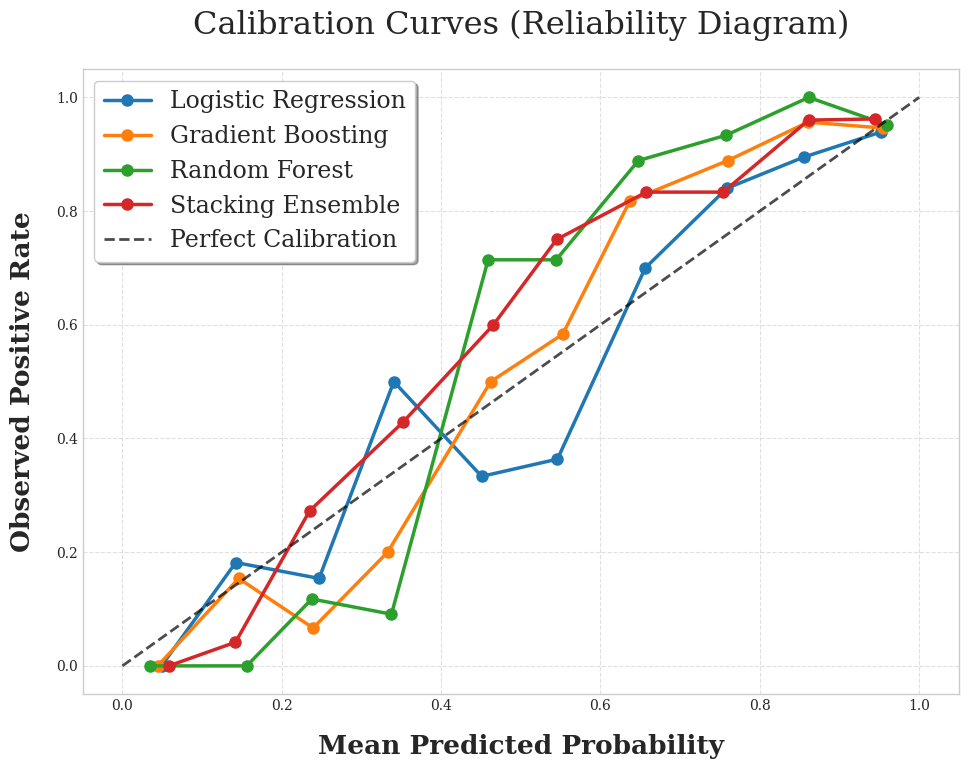


CALIBRATION PERFORMANCE (Brier Score)
         Model Name  Brier Score
Logistic Regression       0.1031
  Gradient Boosting       0.0815
      Random Forest       0.0652
  Stacking Ensemble       0.0611


<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================================================
# CALIBRATION ANALYSIS (Reliability Curves + Brier Score) - NO IMPORTS
# ============================================================================

def calibration_analysis(models_dict, X_test, y_test, n_bins=10, font_size=16):
    """
    Performs calibration analysis with adjustable font sizes.
    """
    # 1. Update global font settings for the current session
    plt.rcParams.update({'font.size': font_size})

    # Increase figure size slightly to accommodate larger text
    plt.figure(figsize=(10, 8))
    calibration_results = []

    for name, model in models_dict.items():
        # Get predicted probabilities for the positive class
        y_proba = model.predict_proba(X_test)[:, 1]

        # Calculate calibration curve
        frac_pos, mean_pred = calibration_curve(
            y_test, y_proba, n_bins=n_bins, strategy='uniform'
        )

        # Plot with thicker lines for better visibility
        plt.plot(mean_pred, frac_pos, marker='o', label=name, linewidth=2.5, markersize=8)

        # Calculate Brier score
        brier = brier_score_loss(y_test, y_proba)
        calibration_results.append({
            'Model Name': name,
            'Brier Score': round(brier, 4)
        })

    # Perfect calibration reference line (y=x)
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', alpha=0.7, linewidth=2)

    # 2. Explicitly set labels and titles with hierarchy
    plt.xlabel('Mean Predicted Probability', fontsize=font_size + 2, fontweight='bold', labelpad=15)
    plt.ylabel('Observed Positive Rate', fontsize=font_size + 2, fontweight='bold', labelpad=15)
    plt.title('Calibration Curves (Reliability Diagram)', fontsize=font_size + 6, pad=25)

    # Legend and grid adjustments
    plt.legend(fontsize=font_size, frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Ensure no labels are cut off
    plt.tight_layout()

    plt.savefig("calibration_curves.png", dpi=1200)
    plt.show()

    # Create DataFrame from results for printing
    calib_df = pd.DataFrame(calibration_results)

    print("\n" + "="*80)
    print("CALIBRATION PERFORMANCE (Brier Score)")
    print("="*80)
    print(calib_df.to_string(index=False))
    print("="*80)

# ============================================================================
# EXECUTION
# ============================================================================
calibration_models = {
    'Logistic Regression': lr_pipeline,
    'Gradient Boosting': gb_pipeline,
    'Random Forest': rf_pipeline,
    'Stacking Ensemble': stacking_pipeline
}

# Adjust 'font_size' here to your preference
calibration_analysis(calibration_models, X_test, y_test, font_size=17)
plt.savefig("lime explanation 1.pdf")


In [ ]:
# ============================================================
# CROSS-MODEL CONSENSUS RATE
# ============================================================

import pandas as pd
import numpy as np

# Collect predictions
pred_df = pd.DataFrame({
    'Logistic Regression': lr_pipeline.predict(X_test),
    'Gradient Boosting': gb_pipeline.predict(X_test),
    'Random Forest': rf_pipeline.predict(X_test),
    'Stacking Ensemble': stacking_pipeline.predict(X_test)
})

# 1️⃣ Full Consensus (all 4 models agree)
full_consensus_rate = (pred_df.nunique(axis=1) == 1).mean() * 100

# 2️⃣ Majority Consensus (at least 3 agree)
majority_consensus_rate = pred_df.apply(
    lambda row: row.value_counts().max() >= 3,
    axis=1
).mean() * 100

print("\n" + "="*70)
print("CROSS-MODEL CONSENSUS ANALYSIS")
print("="*70)
print(f"Full Consensus Rate (All models agree): {full_consensus_rate:.2f}%")
print(f"Majority Consensus Rate (≥3 models agree): {majority_consensus_rate:.2f}%")
print("="*70)
